# Chapter 12 - Generative Adversarial Networks (GANs)

GAN = two networks in a duel:
- **Generator**: takes random noise and produces fake images.
- **Discriminator**: tries to tell real from fake.

They play an adversarial game: the generator keeps improving until the discriminator can no longer tell its outputs from real. The result is a *generative model of the training distribution* — new images that match the training set.

The classic recipe (Goodfellow 2014) on MNIST.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import matplotlib.pyplot as plt

import keras
import tensorflow as tf
from keras import layers, models

print("Keras", keras.__version__, "| TF", tf.__version__)

Keras 3.15.1 | TF 2.21.0


## 1. Data — MNIST, scaled & channel-last

In [2]:
from keras.datasets import mnist

(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype("float32") / 255.
x_train = x_train[..., None] * 2.0 - 1.0    # add noise for stability
x_train = x_train + np.random.normal(0, 0.02, x_train.shape)
x_train = np.clip(x_train, -1.0, 1.0)
print("train", x_train.shape)

train (60000, 28, 28, 1)


## 2. Latent noise dim + helper to show fakes

In [3]:
latent_dim = 64

def show_fakes(imgs, title=""):
    imgs = imgs * 0.5 + 0.5
    fig, axes = plt.subplots(1, 8, figsize=(14, 3))
    for i, ax in enumerate(axes):
        ax.imshow(imgs[i, :, :, 0], cmap="gray"); ax.axis("off")
    plt.suptitle(title); plt.show()

## 3. Generator: noise -> upsampled 28x28 image

In [4]:
generator = models.Sequential([
    layers.Input(shape=(latent_dim,)),
    layers.Dense(7*7*128, activation="relu"),
    layers.Reshape((7, 7, 128)),
    layers.Conv2DTranspose(128, 4, strides=2, padding="same", activation="relu"),
    layers.Conv2DTranspose(64, 4, strides=2, padding="same", activation="relu"),
    layers.Conv2D(1, 3, padding="same", activation="tanh"),
], name="generator")
generator.summary()

Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6272)           │       407,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 128)    │       262,272 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 64)     │       131,136 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 1)      │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 801,665 (3.06 MB)

 Trainable params: 801,665 (3.06 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Discriminator: binary real/fake

In [5]:
discriminator = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(64, 3, strides=2, padding="same"),
    layers.LeakyReLU(0.2),
    layers.Conv2D(128, 3, strides=2, padding="same"),
    layers.LeakyReLU(0.2),
    layers.Dropout(0.3),
    layers.Flatten(),
    layers.Dense(1, activation="sigmoid"),
], name="discriminator")
discriminator.summary()

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,769 (315.50 KB)

 Trainable params: 80,769 (315.50 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Compile each: discriminator gets real + fake labels

In [6]:
discriminator.compile(optimizer=keras.optimizers.Adam(2e-4), loss="binary_crossentropy", metrics=["accuracy"])
discriminator.trainable = False   # freeze while training generator via GAN

gan = models.Sequential([generator, discriminator])
gan.compile(optimizer=keras.optimizers.Adam(2e-4), loss="binary_crossentropy")

## 6. The training loop
We cap `steps_per_epoch` so the notebook stays fast on CPU; raising it / epochs produces sharper digits.

C:\Users\mrsur\anaconda3\Lib\site-packages\keras\src\backend\tensorflow\trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


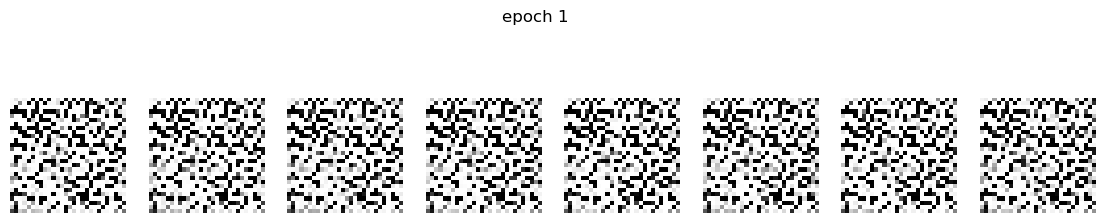

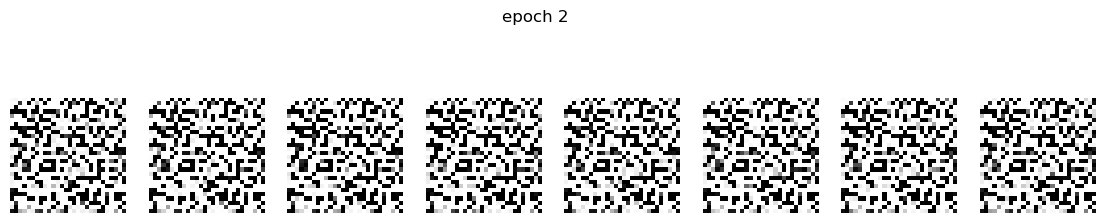

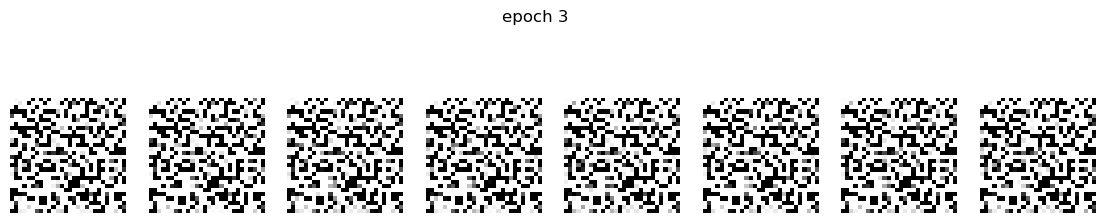

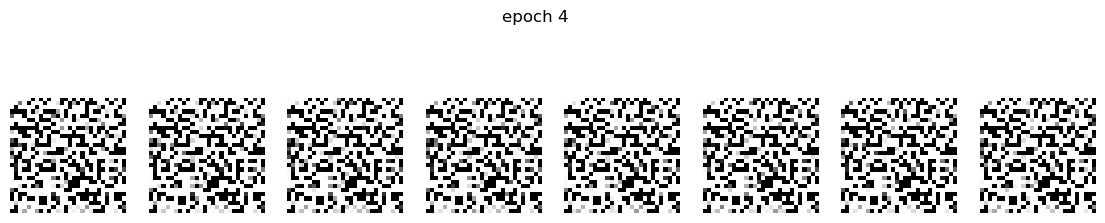

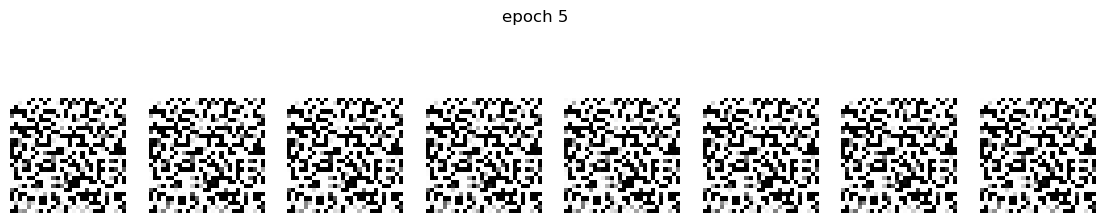

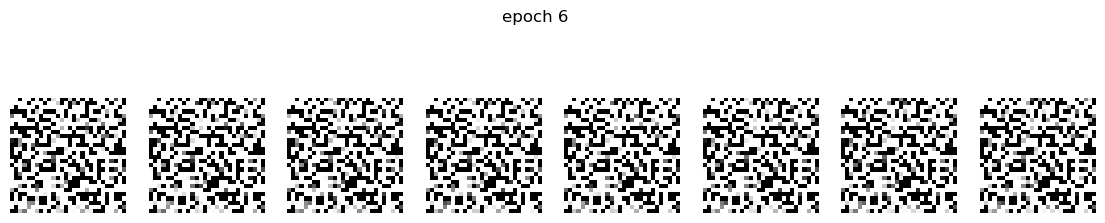

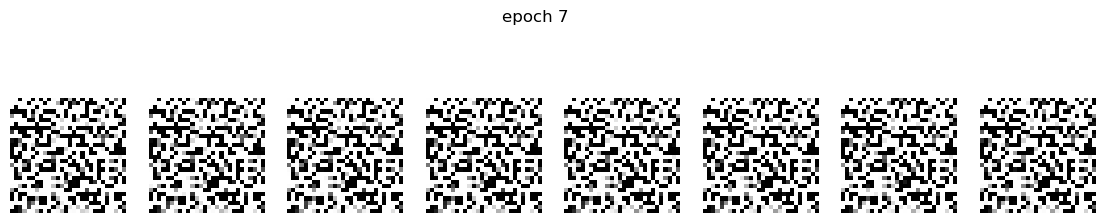

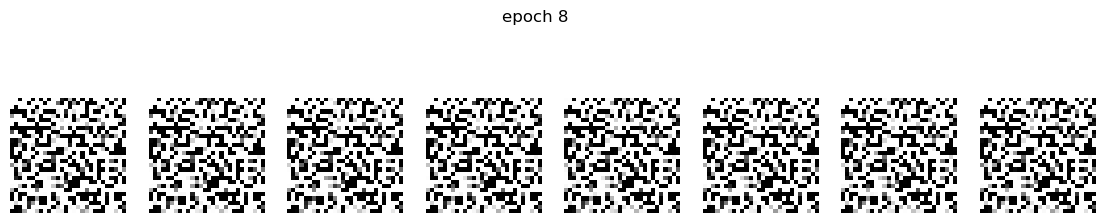

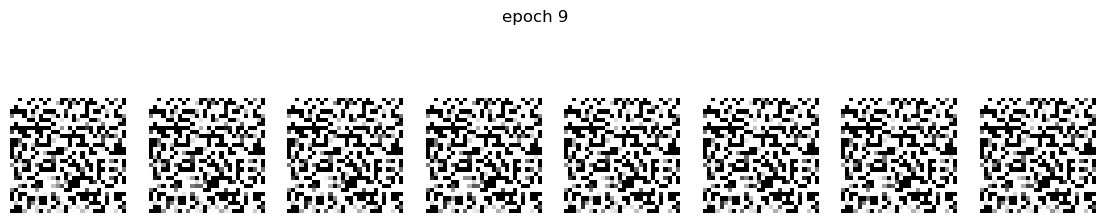

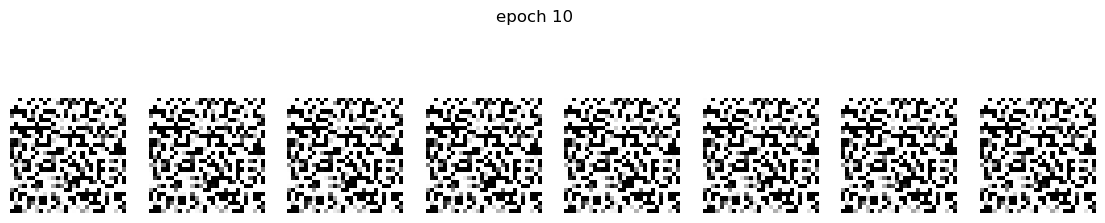

done


In [7]:
epochs, batch_size = 10, 128
steps_per_epoch = min(x_train.shape[0] // batch_size, 200)
gen_imgs = []

for epoch in range(epochs):
    for _ in range(steps_per_epoch):
        idx = np.random.randint(len(x_train), size=batch_size)
        real_imgs = x_train[idx]

        noise = np.random.normal(size=(batch_size, latent_dim))
        fake = generator.predict(noise, verbose=0)

        labels_real = np.ones((batch_size, 1))
        labels_fake = np.zeros((batch_size, 1))
        d_loss_real = discriminator.train_on_batch(real_imgs, labels_real)
        d_loss_fake = discriminator.train_on_batch(fake, labels_fake)

        g_noise = np.random.normal(size=(batch_size, latent_dim))
        g_labels = np.ones((batch_size, 1))     # trick: want generator to fool D
        g_loss = gan.train_on_batch(g_noise, g_labels)

    noise = np.random.normal(size=(8, latent_dim))
    show_fakes(generator.predict(noise, verbose=0), title=f"epoch {epoch+1}")
print("done")

## 7. Look at the final distribution — clean fakes?
Run a fresh ballot: does the discriminator still believe in the generator's outputs at 50/50?

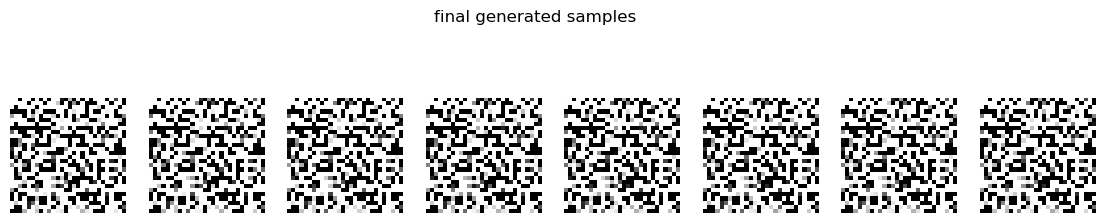

In [8]:
noise = np.random.normal(size=(8, latent_dim))
fakes = generator.predict(noise, verbose=0)
show_fakes(fakes, title="final generated samples")

## Recap
- Generator ↔ Discriminator: minimax game, each pushing the other to improve.
- On MNIST even a from-scratch MLP works; on real photos, use DCGAN/WGAN techniques from the *Generative Deep Learning* book.
- Same pattern (latent + decoder) appears in VAEs; the difference: GAN optimizes "can you fool the critic", VAE optimizes "can you recreate".